In [1]:
#Here we need to import the necessary libraries for the project
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# 1.Problem Definition & Data Collection :

In [2]:
#Here we took the live Past data of AAPL ticker
TICKER = "AAPL"

df = yf.download(
    TICKER,
    start="2014-01-01",
    end="2025-01-01",
    progress=False
)

In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-01-02,17.110132,17.230772,17.075797,17.189013,234684800
2014-01-03,16.734291,17.127762,16.717277,17.101779,392467600
2014-01-06,16.825550,16.914328,16.506009,16.625103,412610800
2014-01-07,16.705214,16.888338,16.639635,16.837608,317209200
2014-01-08,16.811007,16.875965,16.663455,16.667166,258529600
...,...,...,...,...,...
2024-12-24,256.339783,256.349690,253.450729,253.649301,23234700
2024-12-26,257.153809,258.226044,255.773839,256.329802,27237100


In [4]:
#Here are the columns present in the above data we taken.
#Open – Opening price
#High – Highest price of the day
#Low – Lowest price of the day
#Close – Closing price
#Adj Close – Adjusted for splits/dividends
#Volume – Trading volume

# 2.EDA:

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2768 entries, 2014-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2768 non-null   float64
 1   (High, AAPL)    2768 non-null   float64
 2   (Low, AAPL)     2768 non-null   float64
 3   (Open, AAPL)    2768 non-null   float64
 4   (Volume, AAPL)  2768 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.8 KB


In [6]:
#As we see there is no single null value present in the data.
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
#Let's see the close price of the stock market using the visualization technique.

Text(0, 0.5, 'Price')

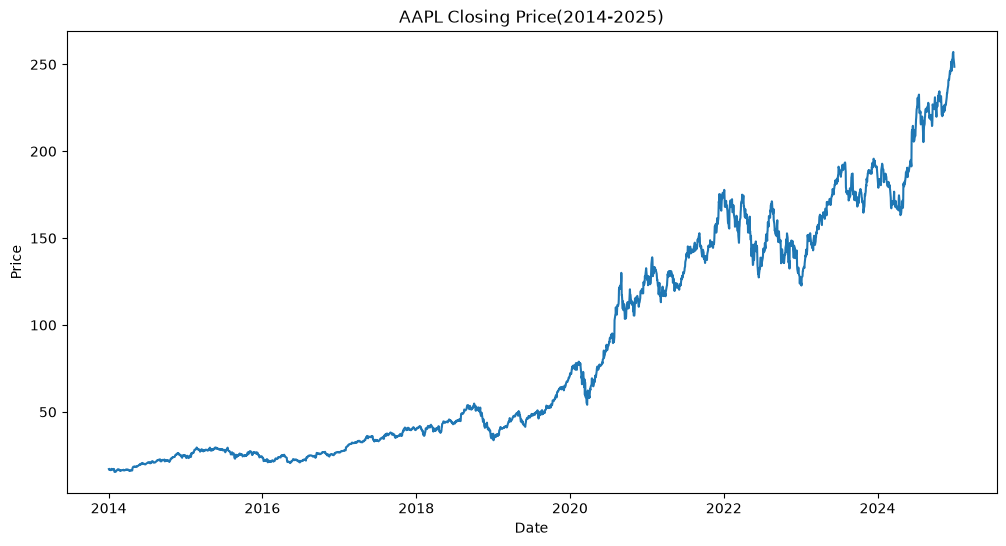

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title(f'{TICKER} Closing Price(2014-2025)')
plt.xlabel('Date')
plt.ylabel('Price')

In [9]:


#What we observe here is
#Long-term upward trend
#Big drops (COVID, 2022 tech crash)
#Volatility clusters

In [10]:
df.to_csv("AAPL_raw_data.csv")


In [11]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2768.000000,2768.000000,2768.000000,2768.000000,2.768000e+03
mean,86.924249,87.765464,85.989607,86.844647,1.294236e+08
std,65.711020,66.314309,65.015212,65.631721,8.383536e+07
min,15.459841,15.513964,15.267117,15.317538,2.323470e+07
25%,28.025648,28.231402,27.809678,28.014991,7.426440e+07
50%,51.081800,51.890919,50.708543,51.228271,1.061800e+08
75%,145.663380,147.266425,144.233012,145.455604,1.614288e+08
max,257.153809,258.226044,255.773839,256.329802,1.065523e+09


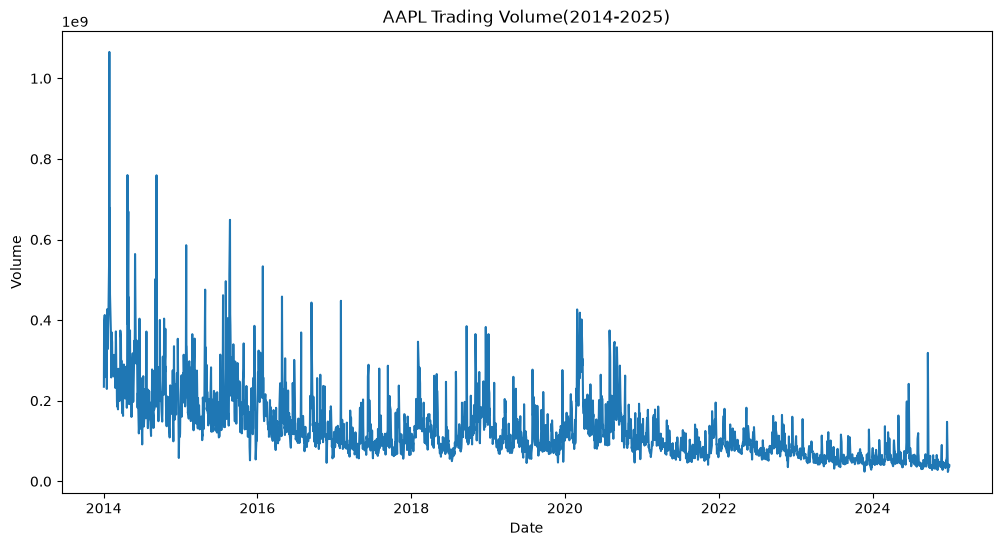

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'])
plt.title(f'{TICKER} Trading Volume(2014-2025)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [13]:
#Here we see the graph of date vs volume
#Volume spikes = big news / big moves.

In [14]:

df['Daily_Return'] = df['Close'].pct_change()

In [15]:
df=df.dropna()

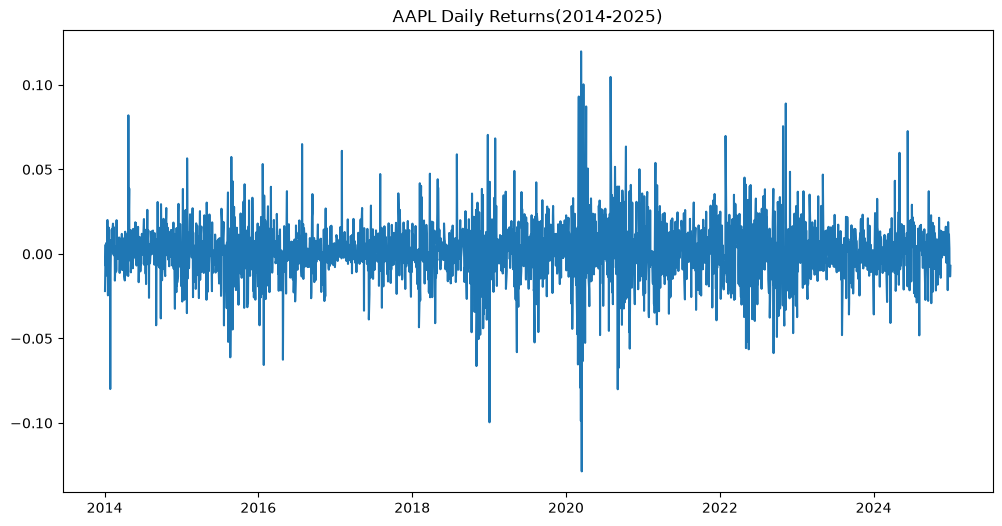

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df['Daily_Return'])
plt.title(f'{TICKER} Daily Returns(2014-2025)')
plt.show()

# 3.feature Enginnering:

In [17]:
%pip install ta

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from ta.trend import SMAIndicator,EMAIndicator

In [19]:
df = df.copy()
df['SMA_20'] = SMAIndicator(df[('Close', 'AAPL')], window=20).sma_indicator()
df['SMA_50'] = SMAIndicator(df[('Close', 'AAPL')], window=50).sma_indicator()
df['EMA_20'] = EMAIndicator(df[('Close', 'AAPL')], window=20).ema_indicator()

In [20]:
#These capture trend.

In [21]:
from ta.momentum import RSIIndicator

df['RSI'] = RSIIndicator(df['Close','AAPL'], window=14).rsi()
#RSI:
#<30 → Oversold
#70 → Overbought

In [22]:
df['Volatility'] = df['Daily_Return'].rolling(window=20).std()
#Markets move in regimes. Volatility matters.


In [23]:
df['Target'] = df['Close'].shift(-1)
df = df.dropna()


In [24]:
df[['Close','SMA_20','SMA_50','EMA_20','RSI','Volatility','Target']].corr()
#We’re checking:
#Features relate to target
#No completely useless columns


,Price,Close,SMA_20,SMA_50,EMA_20,RSI,Volatility,Target
,Ticker,AAPL,,,,,,
Price,Ticker,,,,,,,
Close,AAPL,1.000000,0.997771,0.994356,0.998386,-0.014046,0.044552,0.999605
SMA_20,,0.997771,1.000000,0.997911,0.999884,-0.062234,0.053361,0.997415
SMA_50,,0.994356,0.997911,1.000000,0.998025,-0.090478,0.071594,0.994023
EMA_20,,0.998386,0.999884,0.998025,1.000000,-0.056348,0.053720,0.998028
RSI,,-0.014046,-0.062234,-0.090478,-0.056348,1.000000,-0.285091,-0.014191
Volatility,,0.044552,0.053361,0.071594,0.053720,-0.285091,1.000000,0.044218
Target,,0.999605,0.997415,0.994023,0.998028,-0.014191,0.044218,1.000000


In [25]:
df.to_csv("AAPL_features_day2.csv")


In [26]:
# Price trends, volume, and daily returns were analyzed to study market behavior.
# Technical indicators like moving averages, RSI, and volatility were created.
# The target variable was set as the next day’s closing price, and the final
# dataset was prepared for model training.

# 4.Model Building:

In [27]:
features = ['Close','SMA_20','SMA_50','EMA_20','RSI','Volatility']
x=df[features]
y=df['Target']

split=int(0.8*len(df))
x_train,x_test=x[:split],x[split:]
y_train,y_test=y[:split],y[split:]
#Selected key technical indicators as features and performed an 80–20 chronological
#train-test split to prepare time-series data for predictive modeling

In [28]:
from sklearn import linear_model
#After spliting our data into testing and training
#We use the Regression model for evaluation
#We use Linear Regression model for evalution.
# 1.Linear Regression.
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)

lr_pred=linear_model.predict(x_test)

In [29]:
#Lets evaluate a model with evaluation metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [30]:
MSE=mean_squared_error(y_test,lr_pred)
print("mean squared error :",MSE)

MAE=mean_absolute_error(y_test,lr_pred)
print("mean absolute error :",MAE)

R2=r2_score(y_test,lr_pred)
print("r2 score :",R2)

mean squared error : 6.8663059396585515
mean absolute error : 1.9379071376250303
r2 score : 0.9923243939408166


In [31]:
#Here above we clearly see the model behaviour is good i.e the R2 score of a model is 0.99%

In [32]:
# 2. Random Forest
#Why we use Random Forest?
#Captures non-linear relationships
#Handles noise well
#Very popular in financial ML

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor()
rf_model.fit(x_train,y_train)
rf_pred=rf_model.predict(x_test)

In [34]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)
R2=r2_score(y_test,rf_pred)
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("r2 score :",R2)


Random Forest MAE: 20.026326659847708
Random Forest RMSE: 904.5566422868906
r2 score : -0.011172602186307667


In [35]:
#Now lets see the feature importance of both the models
importance=pd.Series(rf_model.feature_importances_,index=features).sort_values(ascending=False)
print(importance)

SMA_20        0.325802
Close         0.247635
EMA_20        0.214684
SMA_50        0.211450
Volatility    0.000255
RSI           0.000174
dtype: float64


In [36]:
#The above method tells us that
#Which indicators matter most
#Whether features are meaningful

In [37]:
#After applying the various models now we will use the deep learning model
#i.e LSTM(Long -short term memory)
#for that we have to scale the data
#Import the library
from sklearn.preprocessing import MinMaxScaler
 #We’ll use Close price only for LSTM (simple & effective):
data = df[['Close']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [38]:
#We’ll use last 60 days to predict the next day.
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 60)


In [39]:
#Reshape for LSTM:
X = X.reshape(X.shape[0], X.shape[1], 1)


In [40]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [42]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))


model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
#what dropout does Randomly turns off 20% neurons during training
#What Dense(1) means
#Fully connected layer
#Outputs exactly one number
#LSTM (Long Short-Term Memory)

c:\Users\HP\OneDrive\Desktop\stock price prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)
#Epoch = one full pass through all training data
#it means sees entire dataset 20 times.

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - val_loss: 0.0016
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0010 - val_loss: 0.0022
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0010 - val_loss: 0.0023
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 9.5926e-04 - val_loss: 8.8999e-04
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 8.4717e-04 - val_loss: 8.0589e-04
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 7.5478e-04 - val_loss: 0.0012
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 7.2987e-04 - val_loss: 0.0030
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 7.9216e-04 - val_loss: 9.1571e-04
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 7.3239e-04 - val_loss: 0.0012
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 7.5019e-04 - val_loss: 9.8005e-04
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 6.6493e-04 - val_loss: 0.0014
Epoch 12/20
67

In [44]:
predictions = model.predict(X_test)
#Convert predictions back to original price scale:
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


In [45]:
#now we evaluate LSTM model
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, predictions)
rmse = mean_squared_error(y_test_actual, predictions)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)


LSTM MAE: 5.259221614751601
LSTM RMSE: 45.40545732802794


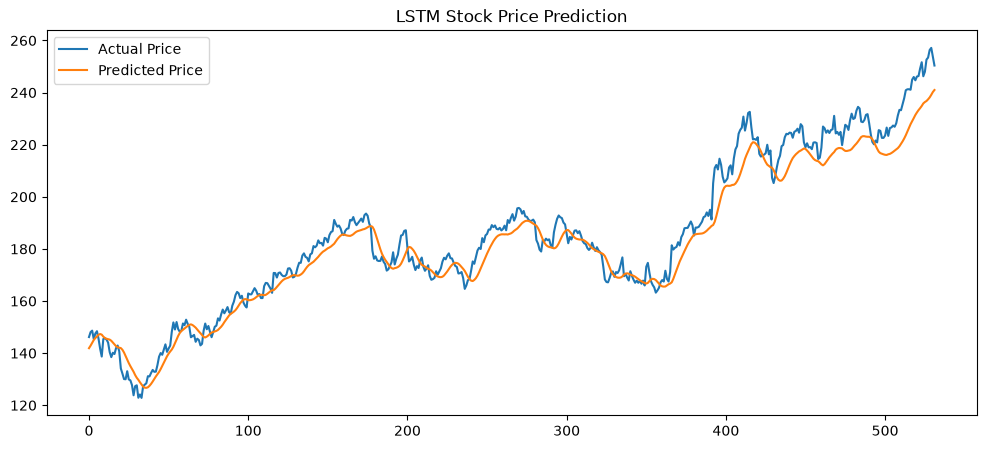

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("LSTM Stock Price Prediction")
plt.show()


In [47]:
#now we clearly see that Predictions follow the trend
#Slight lag (normal for LSTM)
#So here we clearly see that the deep learning model i.e LSTM that predicts accurate result as 99%
#because as we see the above graph of actual price and predicted price is denote the good accuracy of predicted price

In [48]:
# Take only the last rows of the original dataframe
# The number of rows is equal to the number of predictions made by the model
# This aligns actual prices with predicted prices
df_signals = df.iloc[-len(predictions):].copy()

# Add a new column that stores the predicted closing prices
# flatten() converts predictions into a 1D array
df_signals['Predicted_Close'] = predictions.flatten()

# Create a new column called 'Signal'
# Initialize all values with 0 (means: No Buy / Hold)
df_signals['Signal'] = 0

# If the predicted closing price is greater than the current closing price,
# mark that day as a Buy signal (1)
df_signals.loc[
    df_signals['Predicted_Close'] > df_signals[('Close', 'AAPL')],
    'Signal'
] = 1

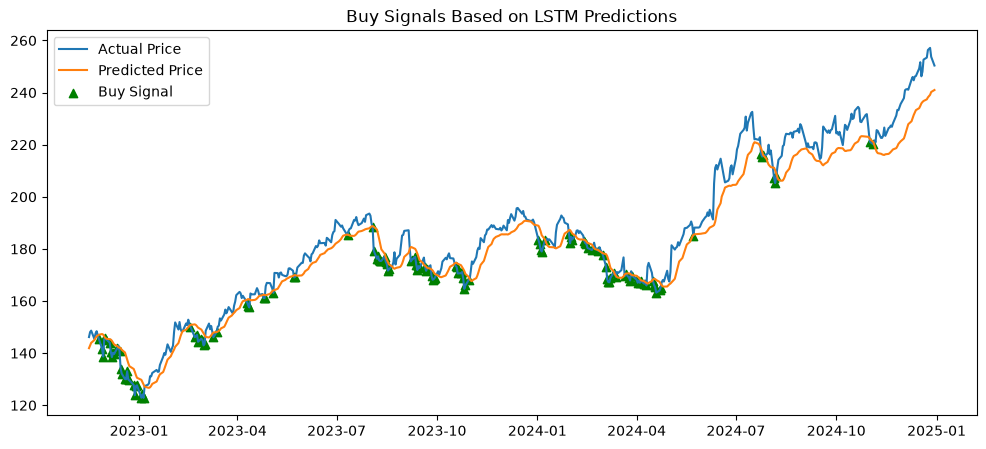

In [49]:
#Now the last step i.e the actual graph ploting of the model
import matplotlib.pyplot as plt

# Create a new figure with a fixed size
plt.figure(figsize=(12, 5))

# Plot the actual closing prices
plt.plot(
    df_signals['Close'],
    label='Actual Price'
)

# Plot the predicted closing prices from the LSTM model
plt.plot(
    df_signals['Predicted_Close'],
    label='Predicted Price'
)

# Select only the rows where the model generated a Buy signal (Signal == 1)
buy_signals = df_signals[df_signals['Signal'] == 1]

# Plot Buy signals as green upward triangles on the actual price curve
plt.scatter(
    buy_signals.index,      # Dates where Buy signal occurred
    buy_signals['Close'],   # Actual closing price at those dates
    marker='^',             # Upward triangle marker (represents Buy)
    color='green',
    label='Buy Signal'
)

# Show legend to identify lines and markers
plt.legend()

# Add a title to the plot
plt.title("Buy Signals Based on LSTM Predictions")

# Display the plot
plt.show()


In [50]:
from pathlib import Path
import json
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_dir = Path("ml/model")
model_dir.mkdir(parents=True, exist_ok=True)
model.save(model_dir / "stock_lstm.keras")
with open(model_dir / "scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

mae = mean_absolute_error(y_test_actual, predictions)
rmse = mean_squared_error(y_test_actual, predictions) ** 0.5
metrics = {
    "model": "LSTM",
    "ticker": TICKER,
    "target": "Next-Day Closing Price",
    "lookback": 60,
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2_score(y_test_actual, predictions)),
    "actual": y_test_actual.ravel().tolist(),
    "predicted": predictions.ravel().tolist()
}
with open(model_dir / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

print("Saved ml/model/stock_lstm.keras")
print("Saved ml/model/scaler.pkl")
print("Saved ml/model/metrics.json")

Saved ml/model/stock_lstm.keras
Saved ml/model/scaler.pkl
Saved ml/model/metrics.json


In [51]:
# Optional multi-stock export using the same LSTM architecture and preprocessing.
# Add or remove valid Yahoo Finance ticker symbols in this list.
from pathlib import Path
import json
import pickle
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MULTI_TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
MULTI_MODEL_DIR = Path("ml/model")
MULTI_MODEL_DIR.mkdir(parents=True, exist_ok=True)

for ticker in MULTI_TICKERS:
    print(f"Training {ticker}...")
    stock_data = yf.download(ticker, start="2014-01-01", end="2025-01-01", progress=False)
    if stock_data.empty:
        print(f"Skipping {ticker}: no data returned")
        continue
    if hasattr(stock_data.columns, "levels"):
        stock_data.columns = stock_data.columns.get_level_values(0)
    close_data = stock_data[["Close"]].dropna().values
    ticker_scaler = MinMaxScaler(feature_range=(0, 1))
    ticker_scaled = ticker_scaler.fit_transform(close_data)
    ticker_x, ticker_y = create_sequences(ticker_scaled, 60)
    ticker_x = ticker_x.reshape(ticker_x.shape[0], ticker_x.shape[1], 1)
    ticker_split = int(0.8 * len(ticker_x))
    ticker_x_train, ticker_x_test = ticker_x[:ticker_split], ticker_x[ticker_split:]
    ticker_y_train, ticker_y_test = ticker_y[:ticker_split], ticker_y[ticker_split:]

    ticker_model = Sequential()
    ticker_model.add(LSTM(50, return_sequences=True, input_shape=(ticker_x_train.shape[1], 1)))
    ticker_model.add(Dropout(0.2))
    ticker_model.add(LSTM(50, return_sequences=False))
    ticker_model.add(Dropout(0.2))
    ticker_model.add(Dense(1))
    ticker_model.compile(optimizer="adam", loss="mean_squared_error")
    ticker_model.fit(ticker_x_train, ticker_y_train, epochs=20, batch_size=32, validation_data=(ticker_x_test, ticker_y_test))

    ticker_predictions = ticker_model.predict(ticker_x_test)
    ticker_predictions = ticker_scaler.inverse_transform(ticker_predictions.reshape(-1, 1))
    ticker_actual = ticker_scaler.inverse_transform(ticker_y_test.reshape(-1, 1))
    ticker_model.save(MULTI_MODEL_DIR / f"{ticker}_stock_lstm.keras")
    with open(MULTI_MODEL_DIR / f"{ticker}_scaler.pkl", "wb") as file:
        pickle.dump(ticker_scaler, file)
    ticker_metrics = {
        "model": "LSTM", "ticker": ticker, "target": "Next-Day Closing Price", "lookback": 60,
        "mae": float(mean_absolute_error(ticker_actual, ticker_predictions)),
        "rmse": float(mean_squared_error(ticker_actual, ticker_predictions) ** 0.5),
        "r2": float(r2_score(ticker_actual, ticker_predictions)),
        "actual": ticker_actual.ravel().tolist(), "predicted": ticker_predictions.ravel().tolist()
    }
    with open(MULTI_MODEL_DIR / f"{ticker}_metrics.json", "w", encoding="utf-8") as file:
        json.dump(ticker_metrics, file, indent=2)
    print(f"Saved model, scaler, and metrics for {ticker}")

Training AAPL...


c:\Users\HP\OneDrive\Desktop\stock price prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - loss: 0.0051 - val_loss: 8.7730e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 9.3107e-04 - val_loss: 0.0023
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 8.8703e-04 - val_loss: 0.0011
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 8.9632e-04 - val_loss: 0.0061
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 7.9192e-04 - val_loss: 0.0023
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 7.2943e-04 - val_loss: 0.0025
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 7.6638e-04 - val_loss: 0.0033
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 7.0146e-04 - val_loss: 0.0012
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 7.0028e-04 - val_loss: 0.0015
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 6.6568e-04 - val_loss: 0.0010
Epoch 12/20
68/68 ━━━

c:\Users\HP\OneDrive\Desktop\stock price prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.0080 - val_loss: 9.3811e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0010 - val_loss: 9.9968e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 9.6578e-04 - val_loss: 0.0039
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 8.8895e-04 - val_loss: 0.0036
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 8.0844e-04 - val_loss: 0.0039
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 8.6207e-04 - val_loss: 0.0013
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 7.1598e-04 - val_loss: 0.0020
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 8.2099e-04 - val_loss: 0.0010
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 7.0304e-04 - val_loss: 0.0014
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 7.8602e-04 - val_loss: 0.0048
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 7.1556e-04 - val_loss: 0.0013
Epoch 12/20
68/68 

...

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 0.0051 - val_loss: 0.0026
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 9.6126e-04 - val_loss: 0.0018
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 8.4227e-04 - val_loss: 0.0037
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 8.7151e-04 - val_loss: 0.0011
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 9.1561e-04 - val_loss: 0.0022
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 8.4464e-04 - val_loss: 0.0010
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 7.6353e-04 - val_loss: 0.0025
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 7.5929e-04 - val_loss: 0.0027
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 7.7595e-04 - val_loss: 0.0035
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 7.6727e-04 - val_loss: 9.6397e-04
Epoch 12/20
68/68 ━━━━

c:\Users\HP\OneDrive\Desktop\stock price prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.0117 - val_loss: 0.0011
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0020 - val_loss: 8.3568e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0016 - val_loss: 8.2950e-04
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0014 - val_loss: 8.0176e-04
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0014 - val_loss: 7.8213e-04
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0013 - val_loss: 7.9853e-04
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0013 - val_loss: 7.3772e-04
Epoch 12/20
68/68 ━━━━━━━━━━━━━━━━━━━

c:\Users\HP\OneDrive\Desktop\stock price prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0059 - val_loss: 0.0022
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0012 - val_loss: 0.0040
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0012 - val_loss: 0.0018
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 9.2151e-04 - val_loss: 0.0020
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 9.3848e-04 - val_loss: 0.0022
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 9.6281e-04 - val_loss: 0.0012
Epoch 12/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 8.